## Sistema de Reconocimiento Facial basado en Eigenfaces

Este notebook implementa un sistema de reconocimiento facial utilizando la técnica de Eigenfaces sobre el conjunto de datos Olivetti Faces, sin el uso de algoritmos de redes neuronales.

### 1. Carga de datos

Cargamos el conjunto de datos 'Olivetti Faces' de `sklearn.datasets` y mostramos sus características principales.

In [ ]:
# Importar las librerías necesarias
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import random

# Cargar el dataset Olivetti Faces
print("Cargando el dataset Olivetti Faces...")
faces = fetch_olivetti_faces()

# Las imágenes están en 'faces.data' y las etiquetas (personas) en 'faces.target'
X = faces.data
y = faces.target

# Mostrar la cantidad de imágenes y sus dimensiones originales
num_imagenes = X.shape[0]
dimensiones_originales = faces.images[0].shape

print(f"\nCantidad de imágenes: {num_imagenes}")
print(f"Dimensiones originales de cada imagen: {dimensiones_originales} (alto x ancho)")
print(f"Cada imagen está aplanada en un vector de {X.shape[1]} píxeles.")
print(f"Número de personas (clases): {len(np.unique(y))}")

Cargando el dataset Olivetti Faces...

Cantidad de imágenes: 400
Dimensiones originales de cada imagen: (64, 64) (alto x ancho)
Cada imagen está aplanada en un vector de 4096 píxeles.
Número de personas (clases): 40


### 2. División del dataset

Dividimos el conjunto de datos en entrenamiento y prueba utilizando un split estratificado para asegurar que todas las 40 personas estén representadas en ambos conjuntos.

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos `stratify=y` para asegurar que la proporción de clases sea la misma en ambos conjuntos
# test_size=0.25 significa que el 25% de los datos se usarán para prueba y el 75% para entrenamiento.
print("\nDividiendo el dataset en conjuntos de entrenamiento y prueba (75%-25% con estratificación)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} imágenes")
print(f"Número de clases en entrenamiento: {len(np.unique(y_train))}")
print(f"Número de clases en prueba: {len(np.unique(y_test))}")


Dividiendo el dataset en conjuntos de entrenamiento y prueba (75%-25% con estratificación)...
Tamaño del conjunto de entrenamiento: 300 imágenes
Tamaño del conjunto de prueba: 100 imágenes
Número de clases en entrenamiento: 40
Número de clases en prueba: 40


### 3. Reducción de dimensionalidad (PCA - Eigenfaces)

Aplicamos el Análisis de Componentes Principales (PCA) para extraer los Eigenfaces. Optaremos por retener el 95% de la varianza para determinar el número óptimo de componentes, o un número fijo si es necesario.

In [ ]:
# Configurar PCA para retener un número fijo de componentes (e.g., 100)
# o para retener un porcentaje de la varianza (usando svd_solver='full' o el predeterminado)
# Para svd_solver='randomized', n_components debe ser un entero.
print("\nAplicando PCA para reducir la dimensionalidad (Eigenfaces)...")
pca = PCA(n_components=100, svd_solver='randomized', whiten=True, random_state=42)

# Ajustar PCA solo en el conjunto de entrenamiento y transformar ambos conjuntos
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

num_componentes = pca.n_components_
print(f"Número de componentes principales (Eigenfaces) seleccionados: {num_componentes}")
print(f"Varianza explicada acumulada: {np.sum(pca.explained_variance_ratio_):.2f}")
print(f"Forma del conjunto de entrenamiento después de PCA: {X_train_pca.shape}")
print(f"Forma del conjunto de prueba después de PCA: {X_test_pca.shape}")


Aplicando PCA para reducir la dimensionalidad (Eigenfaces)...
Número de componentes principales (Eigenfaces) seleccionados: 100
Varianza explicada acumulada: 0.94
Forma del conjunto de entrenamiento después de PCA: (300, 100)
Forma del conjunto de prueba después de PCA: (100, 100)


### 4. Visualización de Eigenfaces

Visualizamos el 'rostro promedio' (mean face) y las primeras 10 Eigenfaces. Las Eigenfaces son los vectores propios que representan las direcciones de máxima varianza en el espacio de las caras.


Visualizando el rostro promedio y las primeras 10 Eigenfaces...


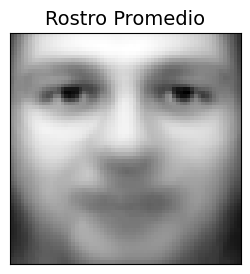

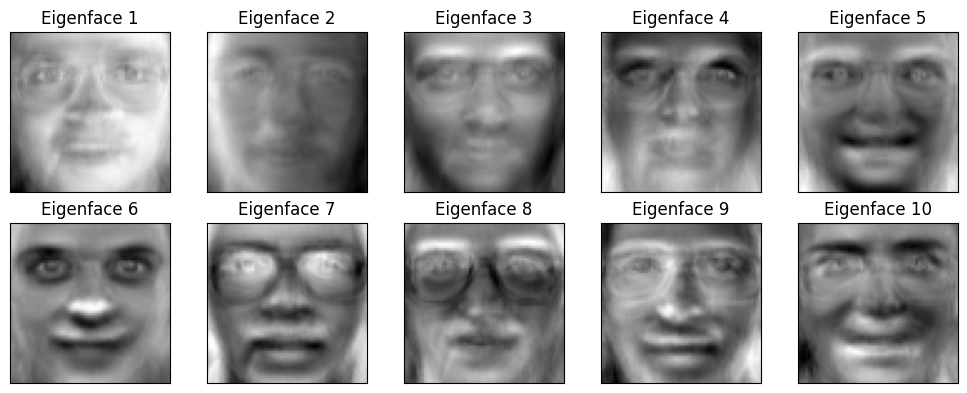

In [ ]:
# Función auxiliar para mostrar caras
def plot_faces(images, titles, h, w, n_row=2, n_col=5, scale_factor=2):
    plt.figure(figsize=(n_col * scale_factor, n_row * scale_factor))
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
    plt.tight_layout()
    plt.show()

# Dimensiones de las imágenes (recordar que son 64x64)
h, w = dimensiones_originales

# Rostro promedio
mean_face = pca.mean_.reshape((h, w))

# Las primeras 10 Eigenfaces
eigenfaces = pca.components_[:10]

eigenface_titles = [f"Eigenface {i+1}" for i in range(eigenfaces.shape[0])]

print("\nVisualizando el rostro promedio y las primeras 10 Eigenfaces...")

# Mostrar el rostro promedio
plt.figure(figsize=(3, 3))
plt.imshow(mean_face, cmap=plt.cm.gray)
plt.title("Rostro Promedio", size=14)
plt.xticks(())
plt.yticks(())
plt.show()

# Mostrar las primeras 10 Eigenfaces
plot_faces(eigenfaces, eigenface_titles, h, w, n_row=2, n_col=5)

### 5. Entrenamiento del Clasificador (SVM)

Utilizamos una Máquina de Vectores de Soporte (SVM) para clasificar los rostros. Realizaremos una búsqueda simple de hiperparámetros (`GridSearchCV`) para `kernel` y `C`.

In [ ]:
print("\nEntrenando el clasificador SVM...")

# Definir el clasificador SVM
svm_classifier = SVC(random_state=42)

# Definir la cuadrícula de parámetros para GridSearchCV
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [1, 10, 100]
}

# Realizar GridSearchCV
print("Realizando GridSearchCV para encontrar los mejores hiperparámetros...")
grid_search = GridSearchCV(svm_classifier, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_pca, y_train)

best_svm_classifier = grid_search.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación de entrenamiento: {grid_search.best_score_:.2f}")

# Entrenar el clasificador con los mejores parámetros encontrados (ya está entrenado por grid_search.best_estimator_)
print("Clasificador SVM entrenado con los mejores parámetros.")


Entrenando el clasificador SVM...
Realizando GridSearchCV para encontrar los mejores hiperparámetros...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros encontrados: {'C': 1, 'kernel': 'linear'}
Mejor puntuación de entrenamiento: 0.88
Clasificador SVM entrenado con los mejores parámetros.


### 6. Evaluación del modelo

Evaluamos el rendimiento del modelo SVM en el conjunto de prueba, calculando la precisión global y mostrando un reporte de clasificación detallado.

In [ ]:
print("\nEvaluando el modelo en el conjunto de prueba...")

# Realizar predicciones en el conjunto de prueba
y_pred = best_svm_classifier.predict(X_test_pca)

# Calcular la precisión global
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión (Accuracy) global en el conjunto de prueba: {accuracy:.4f}")

# Imprimir el reporte de clasificación
print("\nReporte de Clasificación:\n")
print(classification_report(y_test, y_pred, target_names=[f"Persona {i}" for i in range(len(np.unique(y)))]))


Evaluando el modelo en el conjunto de prueba...
Precisión (Accuracy) global en el conjunto de prueba: 0.9700

Reporte de Clasificación:

              precision    recall  f1-score   support

   Persona 0       1.00      1.00      1.00         2
   Persona 1       1.00      1.00      1.00         3
   Persona 2       1.00      1.00      1.00         3
   Persona 3       1.00      1.00      1.00         3
   Persona 4       0.67      1.00      0.80         2
   Persona 5       1.00      1.00      1.00         3
   Persona 6       1.00      1.00      1.00         2
   Persona 7       0.75      1.00      0.86         3
   Persona 8       1.00      1.00      1.00         2
   Persona 9       1.00      0.50      0.67         2
  Persona 10       1.00      1.00      1.00         3
  Persona 11       1.00      1.00      1.00         3
  Persona 12       1.00      1.00      1.00         2
  Persona 13       1.00      1.00      1.00         2
  Persona 14       1.00      1.00      1.00        

### 7. Visualización de predicciones

Mostramos una pequeña galería de imágenes del conjunto de prueba, indicando la etiqueta real y la predicha por el modelo, resaltando si la predicción fue correcta o incorrecta.


Visualizando algunas predicciones del modelo...


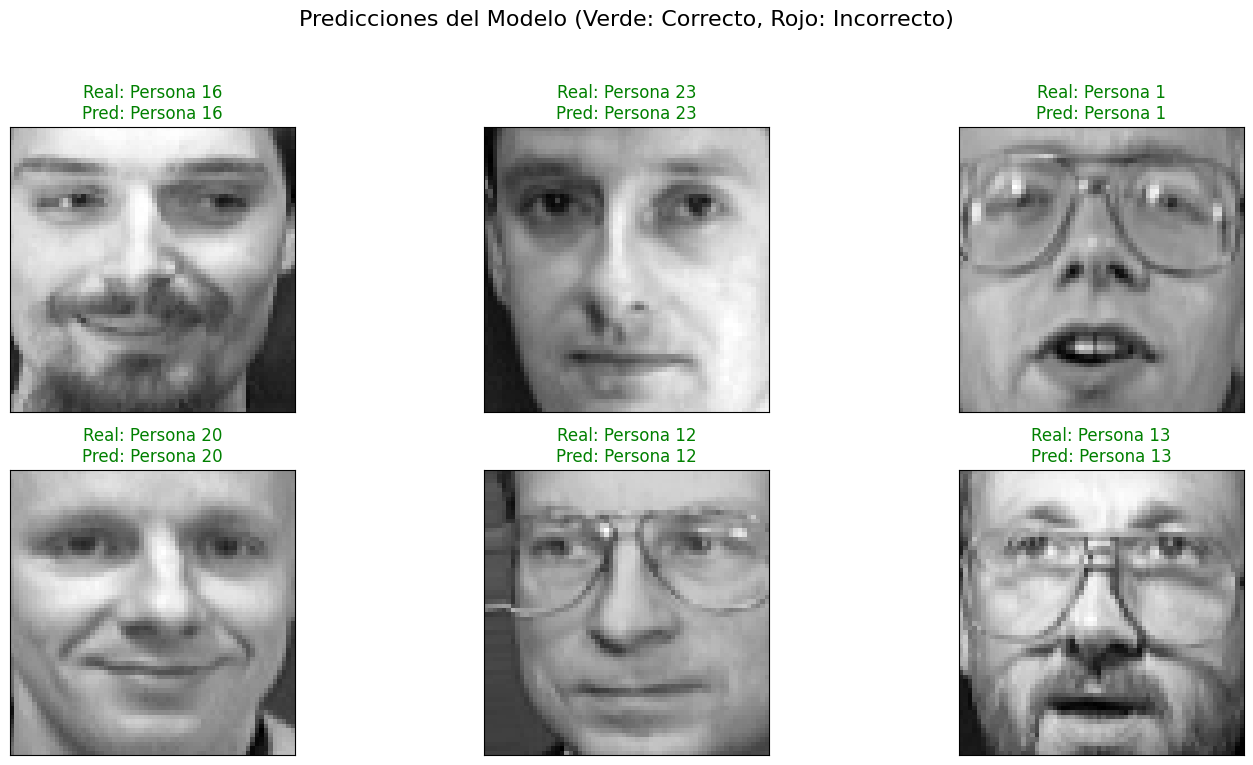

In [ ]:
print("\nVisualizando algunas predicciones del modelo...")

# Obtener los nombres de las personas (simplemente los IDs)
person_names = [f"Persona {i}" for i in range(len(np.unique(y)))]

# Seleccionar un subconjunto aleatorio de imágenes del conjunto de prueba para visualizar
num_to_show = 6
indices = random.sample(range(len(X_test)), num_to_show)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    # Reconstruir la imagen original para visualización
    # Aunque la predicción se hizo en el espacio PCA, visualizamos la imagen original
    image = X_test[idx].reshape(h, w)
    true_label = y_test[idx]
    predicted_label = y_pred[idx]

    plt.subplot(2, (num_to_show + 1) // 2, i + 1)
    plt.imshow(image, cmap=plt.cm.gray)

    title_color = 'green' if true_label == predicted_label else 'red'
    title_text = f"Real: {person_names[true_label]}\nPred: {person_names[predicted_label]}"
    plt.title(title_text, color=title_color, fontsize=12)
    plt.xticks(())
    plt.yticks(())

plt.suptitle("Predicciones del Modelo (Verde: Correcto, Rojo: Incorrecto)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para título superior
plt.show()